In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('loaded all dependencies successfully...')

loaded all dependencies successfully...


In [13]:
df = pd.read_csv('D:\\Krishna\\ML Projects\\Churn Prediction\\data\\customer_churn.csv')
print('loaded the dataset successfully...')

loaded the dataset successfully...


In [14]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

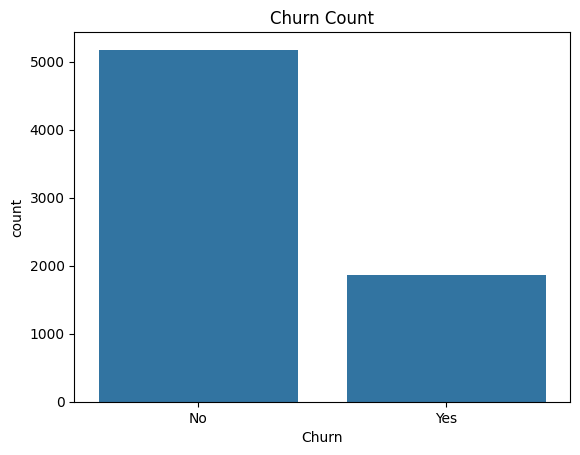

In [15]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Count')
plt.show()

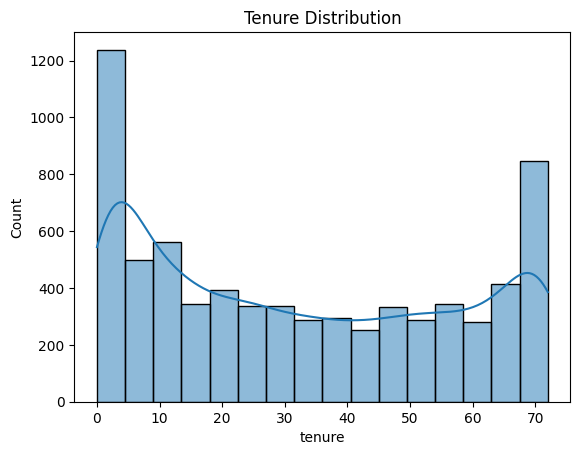

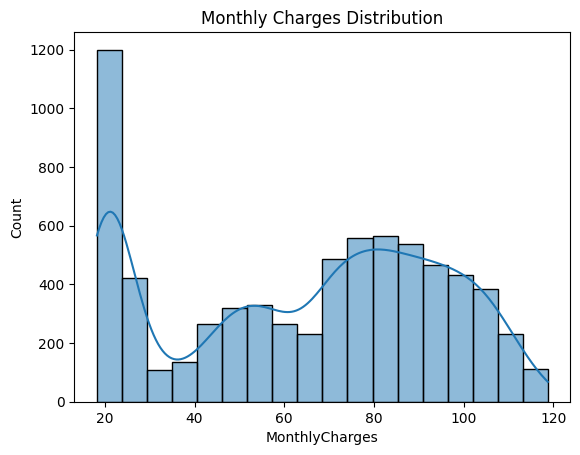

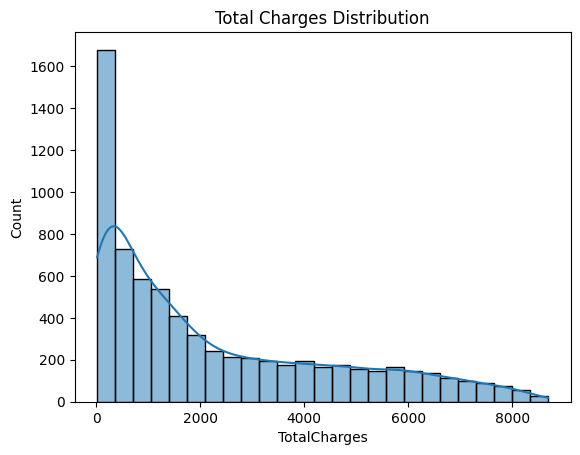

Skew Values :-
tenure = 0.240
MonthlyCharges = -0.221
TotalCharges = 0.962


In [16]:
sns.histplot(df['tenure'], kde=True)
plt.title('Tenure Distribution')
plt.show()
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title('Monthly Charges Distribution')
plt.show()
sns.histplot(pd.to_numeric(df['TotalCharges'], errors='coerce'), kde=True)
plt.title('Total Charges Distribution')
plt.show()

print('Skew Values :-')
print(f'tenure = {df['tenure'].skew():.3f}')
print(f'MonthlyCharges = {df['MonthlyCharges'].skew():.3f}')
print(f'TotalCharges = {pd.to_numeric(df['TotalCharges'], errors='coerce').skew():.3f}')


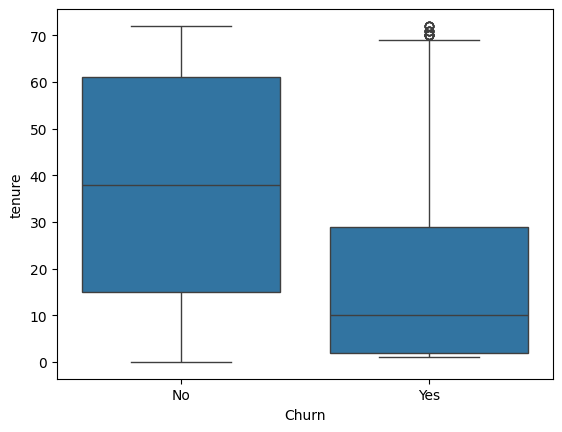

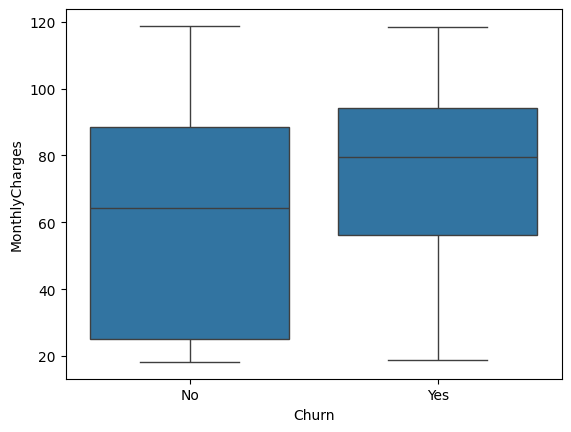

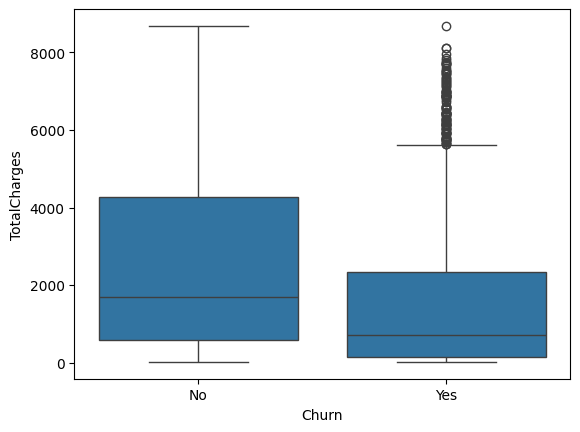

In [17]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

sns.boxplot(x=df['Churn'], y=pd.to_numeric(df['TotalCharges'], errors='coerce'))
plt.show()


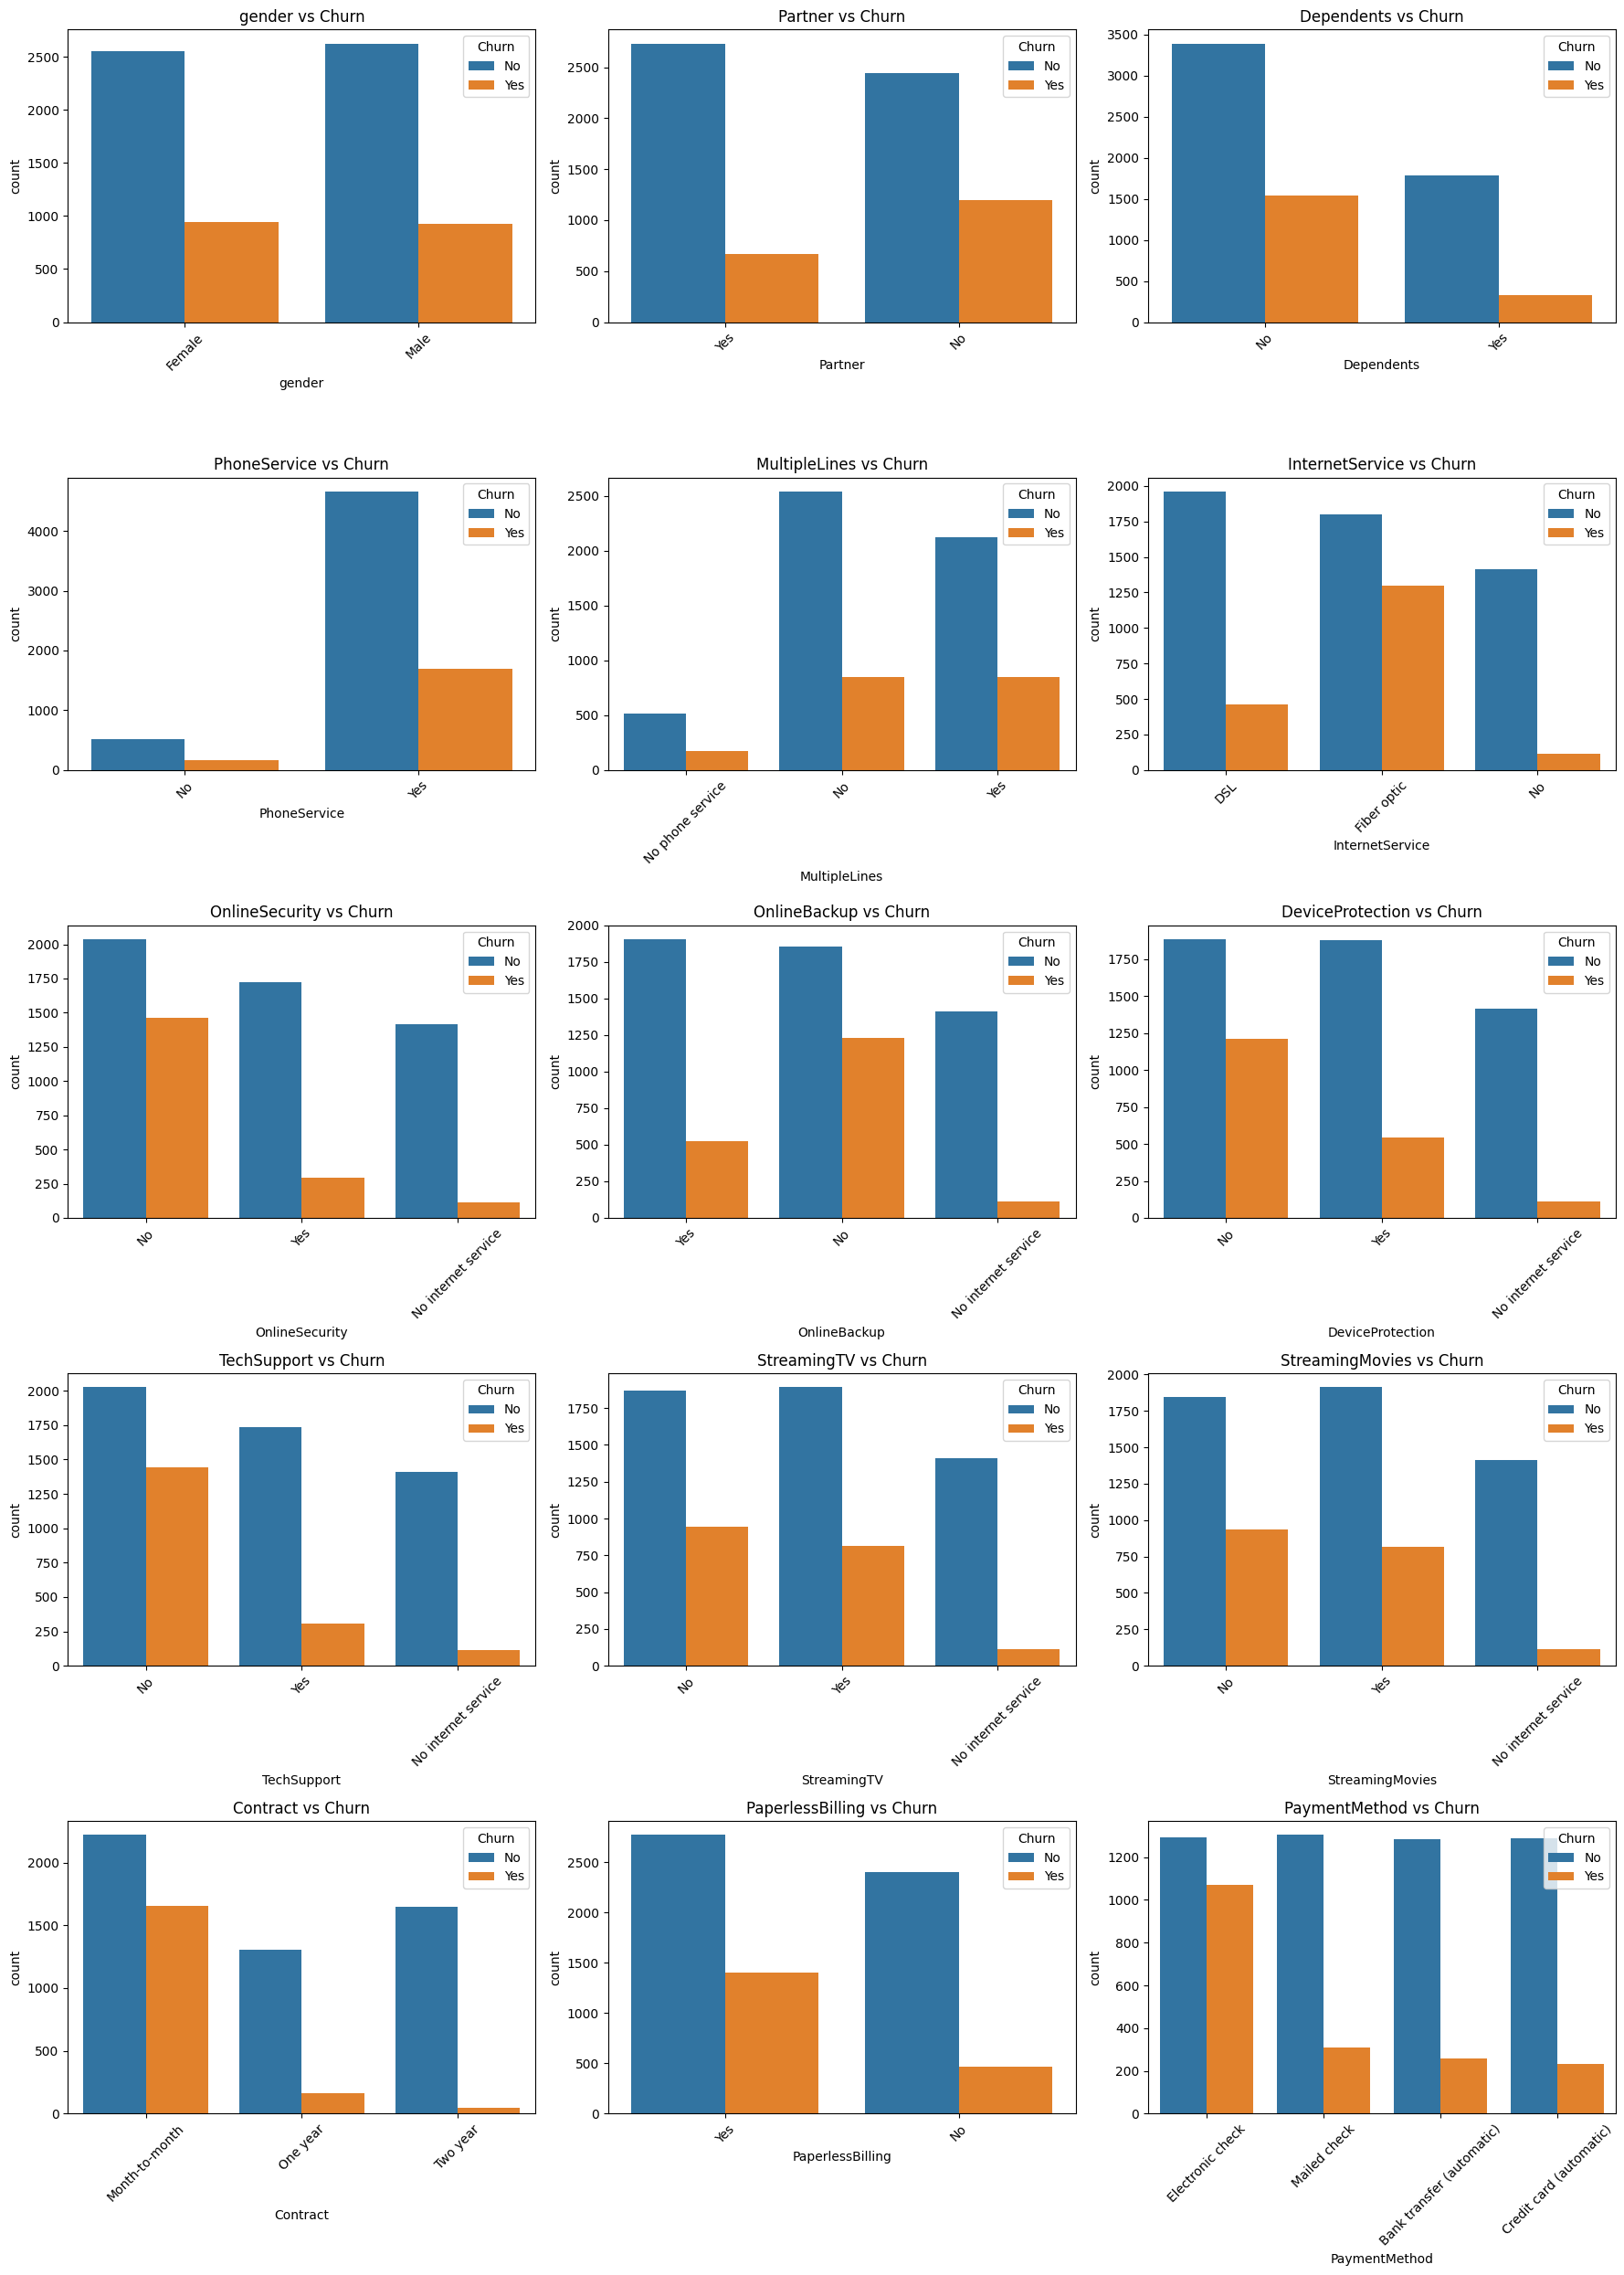

In [18]:
# List of categorical features to compare with Churn
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# Set up 3 columns and 5 rows for subplots
n_cols = 3
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

for idx, feature in enumerate(categorical_features):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    sns.countplot(x=feature, hue="Churn", data=df, ax=ax)
    ax.set_title(f"{feature} vs Churn")
    # Set tick rotation after setting the correct tick positions
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
total_plots = n_rows * n_cols
if len(categorical_features) < total_plots:
    for j in range(len(categorical_features), total_plots):
        fig.delaxes(axes[j // n_cols, j % n_cols])

plt.tight_layout()
plt.show()

In [22]:
for col in categorical_features:
    print(df.groupby(col)['Churn'].value_counts(normalize=True))


gender  Churn
Female  0        0.730791
        1        0.269209
Male    0        0.738397
        1        0.261603
Name: proportion, dtype: float64
Partner  Churn
No       0        0.670420
         1        0.329580
Yes      0        0.803351
         1        0.196649
Name: proportion, dtype: float64
Dependents  Churn
No          0        0.687209
            1        0.312791
Yes         0        0.845498
            1        0.154502
Name: proportion, dtype: float64
PhoneService  Churn
No            0        0.750733
              1        0.249267
Yes           0        0.732904
              1        0.267096
Name: proportion, dtype: float64
MultipleLines     Churn
No                0        0.749558
                  1        0.250442
No phone service  0        0.750733
                  1        0.249267
Yes               0        0.713901
                  1        0.286099
Name: proportion, dtype: float64
InternetService  Churn
DSL              0        0.810409
          

In [20]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

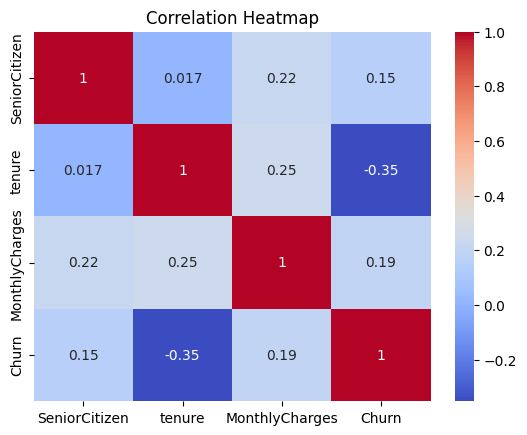

In [21]:
corr = df.corr(numeric_only=True)

# Set vmin/vmax to force colormap contrast (avoid all-white look if 'Churn' has low/no correlation)
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Summary

### Class Imbalance
- The dataset is imbalanced: ~27% churn vs ~73% non-churn  
- This needs to be considered during model evaluation (accuracy alone may be misleading)

---

### Numerical Features

#### Tenure
- Distribution shows two peaks (new and long-term customers)
- Customers with lower tenure are significantly more likely to churn  
- Clear separation between churn and non-churn groups, indicating strong predictive power  

#### MonthlyCharges
- Bimodal distribution indicating two customer segments  
- Churned customers tend to have slightly higher monthly charges  
- However, there is significant overlap between churn and non-churn groups, making it a weaker standalone predictor  

#### TotalCharges
- Right-skewed distribution with most values concentrated at lower ranges  
- Lower total charges are associated with churn  
- This is largely influenced by tenure, as new customers (low tenure) naturally have low total charges  

---

### Categorical Features

- **Gender** shows no significant relationship with churn  

- Customers **without Partner or Dependents** show higher churn rates  

- **InternetService**:
  - Fiber optic users have a higher proportion of churn compared to DSL users  

- **Contract Type**:
  - Month-to-month contracts have the highest churn rates  
  - Long-term contracts are associated with lower churn  

- **Payment Method**:
  - Customers using electronic check show higher churn  

- **Service-related Features**:
  - Lack of services such as OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport is associated with higher churn  
  - PaperlessBilling is also associated with increased churn  

- Some features (PhoneService, MultipleLines, StreamingTV, StreamingMovies) have skewed distributions, making it difficult to draw strong conclusions about their relationship with churn  

---

### Correlation

- **Tenure** has a moderate negative correlation with churn (~ -0.35), indicating that longer-tenure customers are less likely to churn  

- **MonthlyCharges** shows a weak positive correlation with churn  

- Overall, correlations are not very strong, suggesting that churn depends on a combination of multiple features rather than a single dominant factor  

---

### Final Key Insights

- Customers with lower tenure are significantly more likely to churn  
- Month-to-month contracts are a major driver of churn  
- Higher monthly charges are associated with increased churn  
- Fiber optic users show higher churn compared to other internet service types  
- Lack of additional services (security, backup, support) increases churn likelihood  
- The dataset is imbalanced, requiring careful choice of evaluation metrics  